In [39]:
#Import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

#Extracting data from the CSV file and making a dataframe
df = pd.read_csv("Thermal_Conductivity_prediction_Dataset.csv")
#Handle Missing Values
print(df.isnull().sum())
df.head()

Particle Material                        0
Base Fluid                               0
Temperature (°C)                         0
Particle Size (nm)                       0
Particle Volume Fraction (in %)          0
Thermal Conductivity of Liquid (km)      0
Thermal Conductivity of Particle (kp)    0
Exp-TC                                   0
KKL-TC                                   0
dtype: int64


,Particle Material,Base Fluid,Temperature (°C),Particle Size (nm),Particle Volume Fraction (in %),Thermal Conductivity of Liquid (km),Thermal Conductivity of Particle (kp),Exp-TC,KKL-TC
0,Al₂O₃,Water,20,150,0.5,0.5984,27,0.607376,0.993655
1,Al₂O₃,Water,30,150,0.5,0.6155,27,0.630888,0.991569
2,Al₂O₃,Water,40,150,0.5,0.6306,27,0.649518,0.989927
3,Al₂O₃,Water,50,150,0.5,0.6436,27,0.671275,0.988566
4,Al₂O₃,Water,20,150,1.0,0.5984,27,0.613360,0.989888


In [40]:
#Encoding our data using the LabelEncoding method
leparticle = LabelEncoder()
lefluid = LabelEncoder()
df["Particle_enc"] = leparticle.fit_transform(df["Particle Material"])
df["Fluid_enc"] = lefluid.fit_transform(df["Base Fluid"])

#Pre-Processing the data
df["Enhancement"] = df["Exp-TC"] - df["Thermal Conductivity of Liquid (km)"]
df["kp_km_ratio"] = (
    df["Thermal Conductivity of Particle (kp)"] /
    df["Thermal Conductivity of Liquid (km)"]
)
df.head()

,Particle Material,Base Fluid,Temperature (°C),Particle Size (nm),Particle Volume Fraction (in %),Thermal Conductivity of Liquid (km),Thermal Conductivity of Particle (kp),Exp-TC,KKL-TC,Particle_enc,Fluid_enc,Enhancement,kp_km_ratio
0,Al₂O₃,Water,20,150,0.5,0.5984,27,0.607376,0.993655,1,2,0.008976,45.120321
1,Al₂O₃,Water,30,150,0.5,0.6155,27,0.630888,0.991569,1,2,0.015387,43.866775
2,Al₂O₃,Water,40,150,0.5,0.6306,27,0.649518,0.989927,1,2,0.018918,42.816365
3,Al₂O₃,Water,50,150,0.5,0.6436,27,0.671275,0.988566,1,2,0.027675,41.951523
4,Al₂O₃,Water,20,150,1.0,0.5984,27,0.613360,0.989888,1,2,0.014960,45.120321


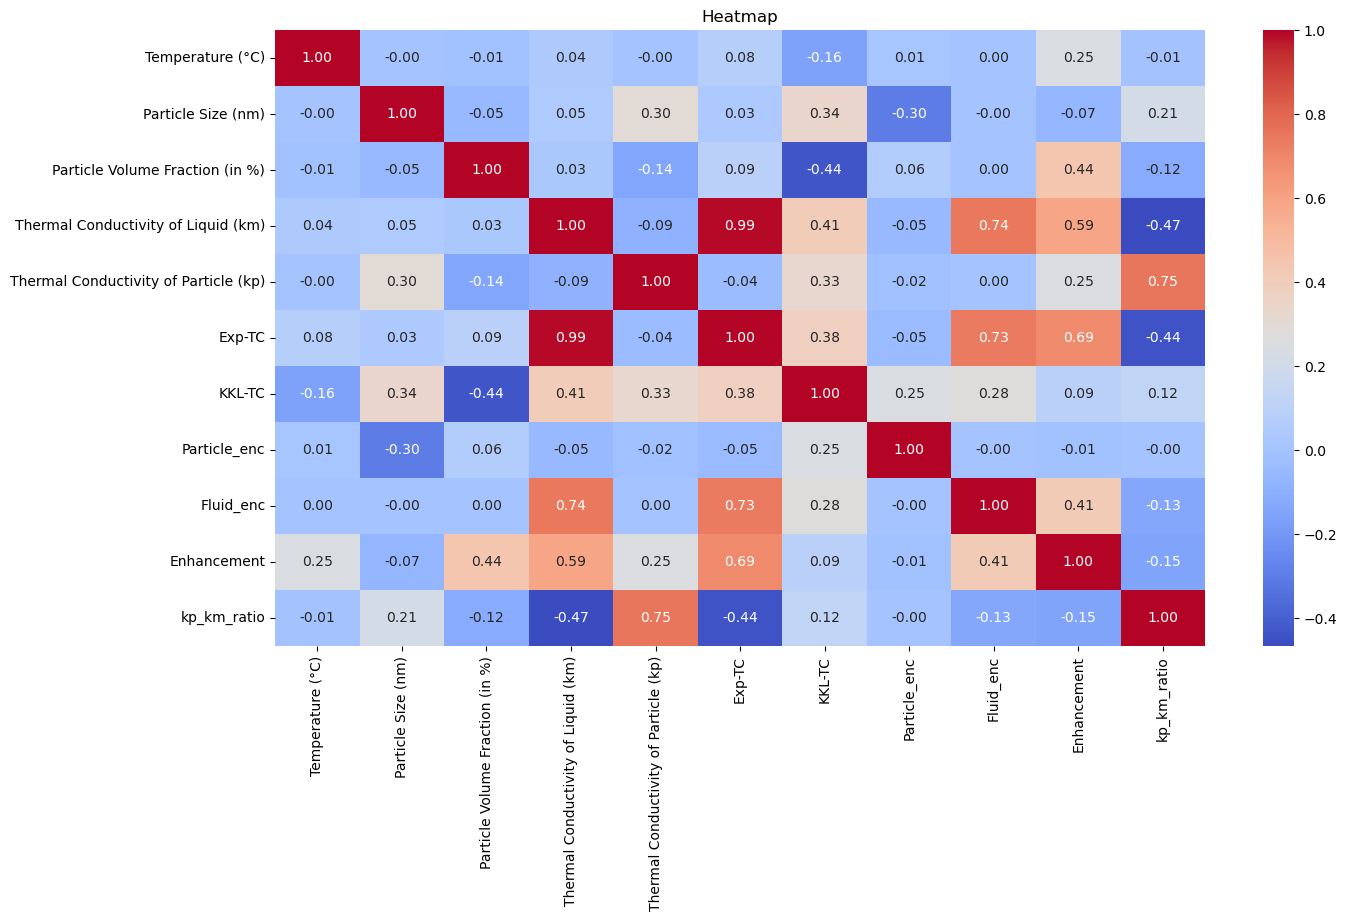

In [41]:
#Features Selection
features = [
    "Particle_enc",
    "Fluid_enc",
    "Temperature (°C)",
    "Particle Size (nm)",
    "Particle Volume Fraction (in %)",
    "Thermal Conductivity of Particle (kp)",
    "kp_km_ratio"
]
X = df[features]
y = df["Enhancement"]

#Heatmap
plt.figure(figsize=(15, 8))
corr_matrix=df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap")
plt.show()

In [42]:
#Training-Testing-Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [43]:
#Training and Predicting the results of a Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_lr = model.predict(X_test_scaled)

R2 Score: 0.7934506018867837
Mean Absolute Error: 0.012651790050532635
Root Mean Squared Error: 0.016464149068414643


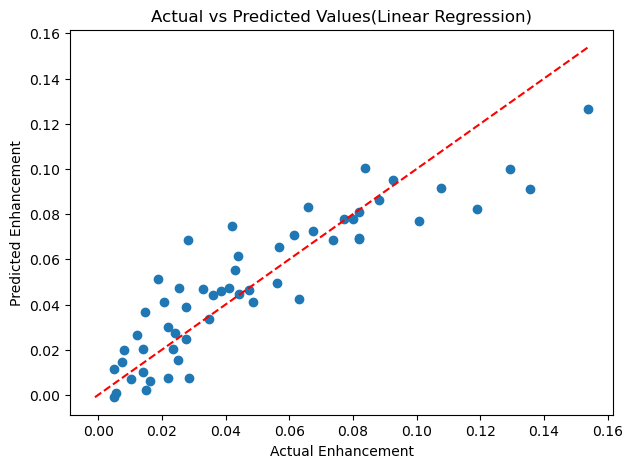

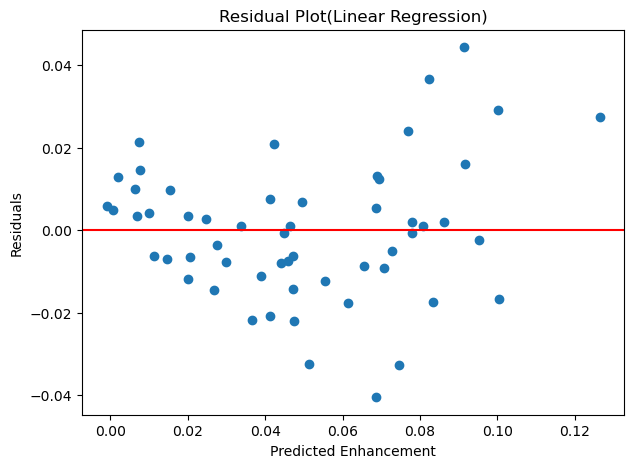

In [44]:
#Evaluation of LinearRegression model
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

#Actual v/s Predicted Values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], "--r")
plt.xlabel("Actual Enhancement")
plt.ylabel("Predicted Enhancement")
plt.title("Actual vs Predicted Values(Linear Regression)")
plt.show()

#Residual Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_lr, y_test - y_pred_lr)
plt.axhline(y=0, color="red", linestyle="-")
plt.xlabel("Predicted Enhancement")
plt.ylabel("Residuals")
plt.title("Residual Plot(Linear Regression)")
plt.show()

In [45]:
#Training the Model using Support Vector Regression(SVR)
model = SVR(kernel="rbf", C=100, epsilon=0.01)
model.fit(X_train_scaled, y_train)
y_pred_svr = model.predict(X_test_scaled)

R2 Score: 0.9230435743008748
Mean Absolute Error: 0.007856953733527957
Root Mean Squared Error: 0.010049622927664991


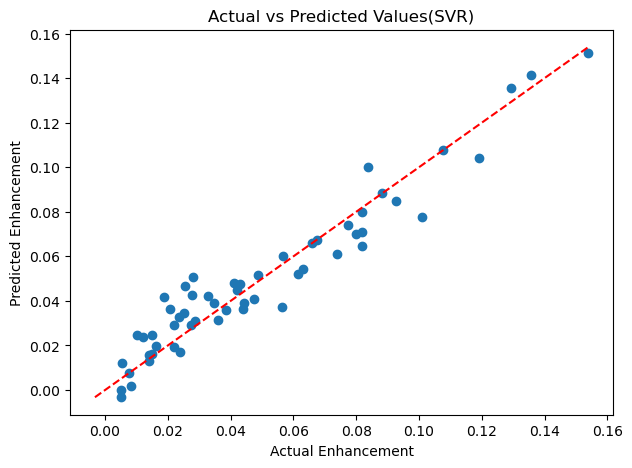

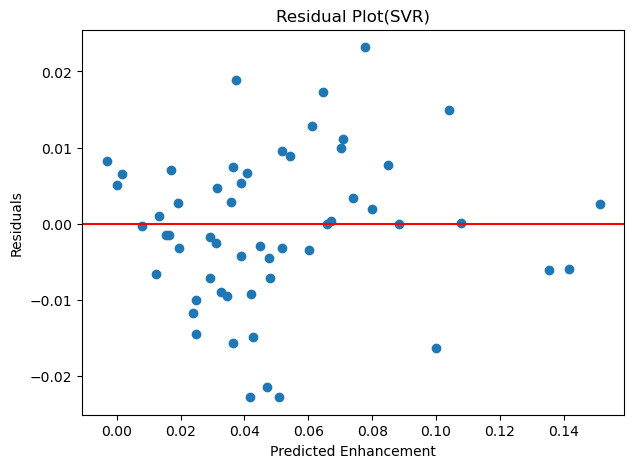

In [46]:
#Evaluation of Support Vector Regression(SVR) model
r2 = r2_score(y_test, y_pred_svr)
mae = mean_absolute_error(y_test, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr ))
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

#Actual v/s Predicted Values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_svr)
min_val = min(y_test.min(), y_pred_svr.min())
max_val = max(y_test.max(), y_pred_svr.max())
plt.plot([min_val, max_val], [min_val, max_val], "--r")
plt.xlabel("Actual Enhancement")
plt.ylabel("Predicted Enhancement")
plt.title("Actual vs Predicted Values(SVR)")
plt.show()

#Residual Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_svr, y_test - y_pred_svr)
plt.axhline(y=0, color="red", linestyle="-")
plt.xlabel("Predicted Enhancement")
plt.ylabel("Residuals")
plt.title("Residual Plot(SVR)")
plt.show()

In [47]:
#Training the Random Forest Regressor Model
model = RandomForestRegressor(n_estimators=200,random_state=42)
model.fit(X_train, y_train)
y_pred_rf= model.predict(X_test)

R2 Score: 0.9081494363405752
Mean Absolute Error: 0.007338847660714283
Root Mean Squared Error: 0.010979137790316474


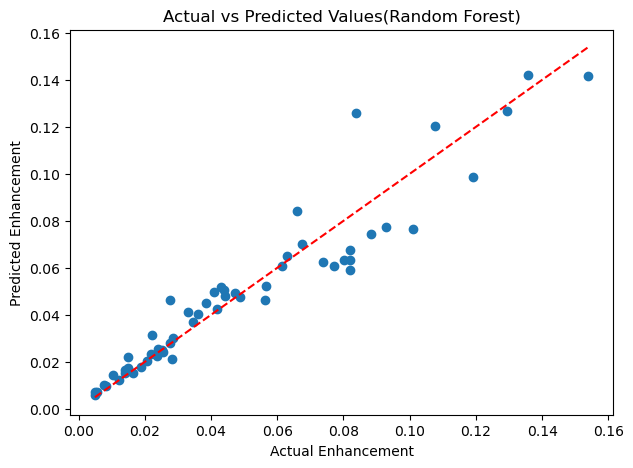

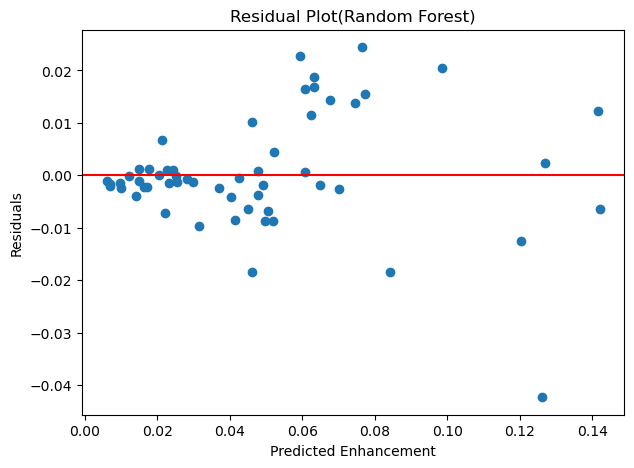

In [48]:
#Evaluation of Random Forest model
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_rf ))
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

#Actual v/s Predicted Values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], "--r")
plt.xlabel("Actual Enhancement")
plt.ylabel("Predicted Enhancement")
plt.title("Actual vs Predicted Values(Random Forest)")
plt.show()

#Residual Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_rf, y_test - y_pred_rf)
plt.axhline(y=0, color="red", linestyle="-")
plt.xlabel("Predicted Enhancement")
plt.ylabel("Residuals")
plt.title("Residual Plot(Random Forest)")
plt.show()

In [49]:
#Training the eXtreme Gradient Boosting(XGBoost) Regressor model
model = XGBRegressor(n_estimators=200,random_state=42,verbosity=0)
model.fit(X_train, y_train)
y_pred_xgb = model.predict(X_test)

R2 Score: 0.9095044013581325
Mean Absolute Error: 0.0072694158581001435
Root Mean Squared Error: 0.010897855657388213


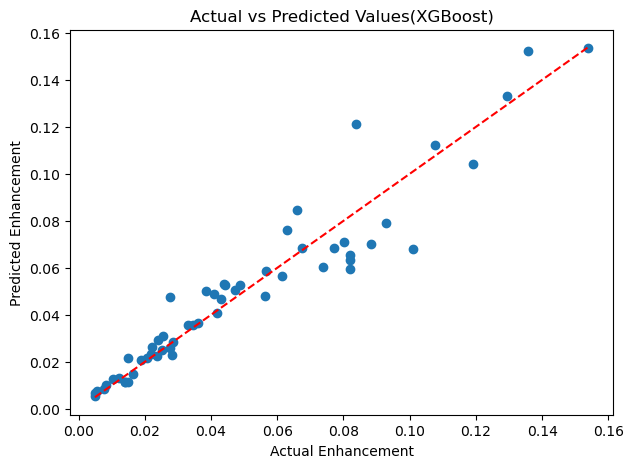

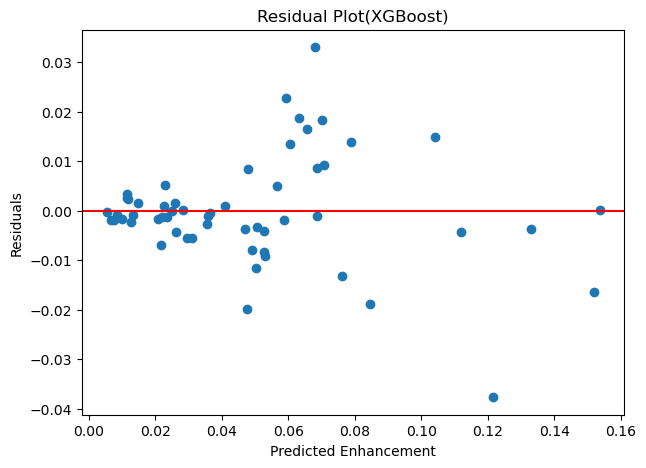

In [50]:
#Evaluation of eXtreme Gradient Boosting(XGBoost) Regressor model
r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_xgb ))
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

#Actual v/s Predicted Values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_xgb)
min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], "--r")
plt.xlabel("Actual Enhancement")
plt.ylabel("Predicted Enhancement")
plt.title("Actual vs Predicted Values(XGBoost)")
plt.show()

#Residual Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_xgb, y_test - y_pred_xgb)
plt.axhline(y=0, color="red", linestyle="-")
plt.xlabel("Predicted Enhancement")
plt.ylabel("Residuals")
plt.title("Residual Plot(XGBoost)")
plt.show()

           Model        R2       MAE      RMSE
0             LR  0.793451  0.012652  0.016464
1            SVR  0.923044  0.007857  0.010050
2  Random Forest  0.908149  0.007339  0.010979
3        XGBoost  0.909504  0.007269  0.010898


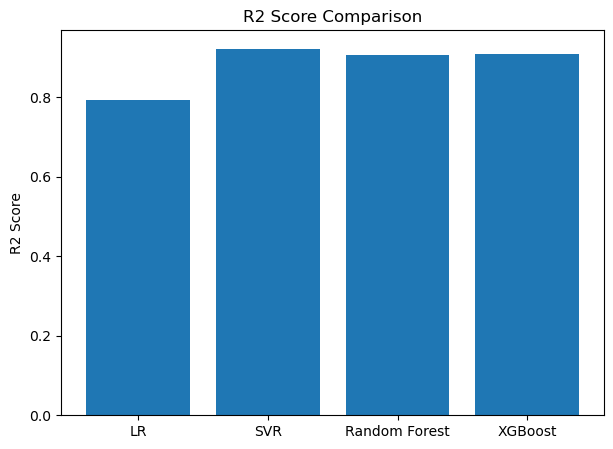

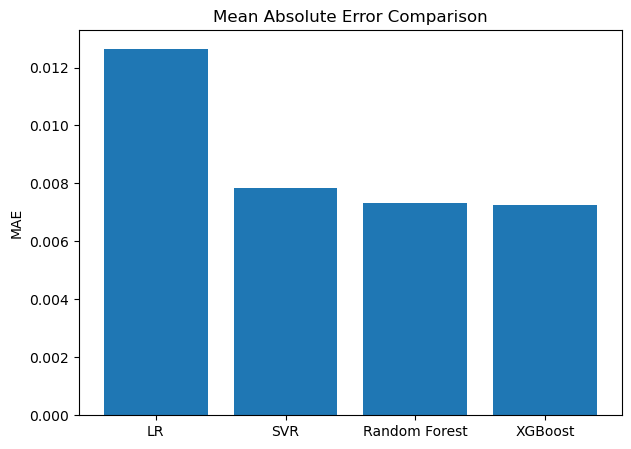

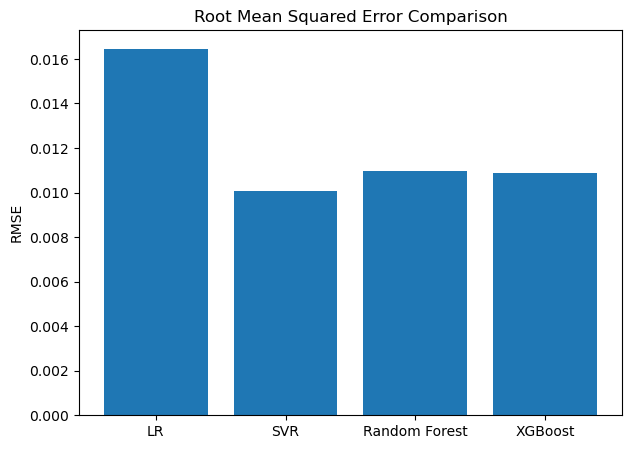

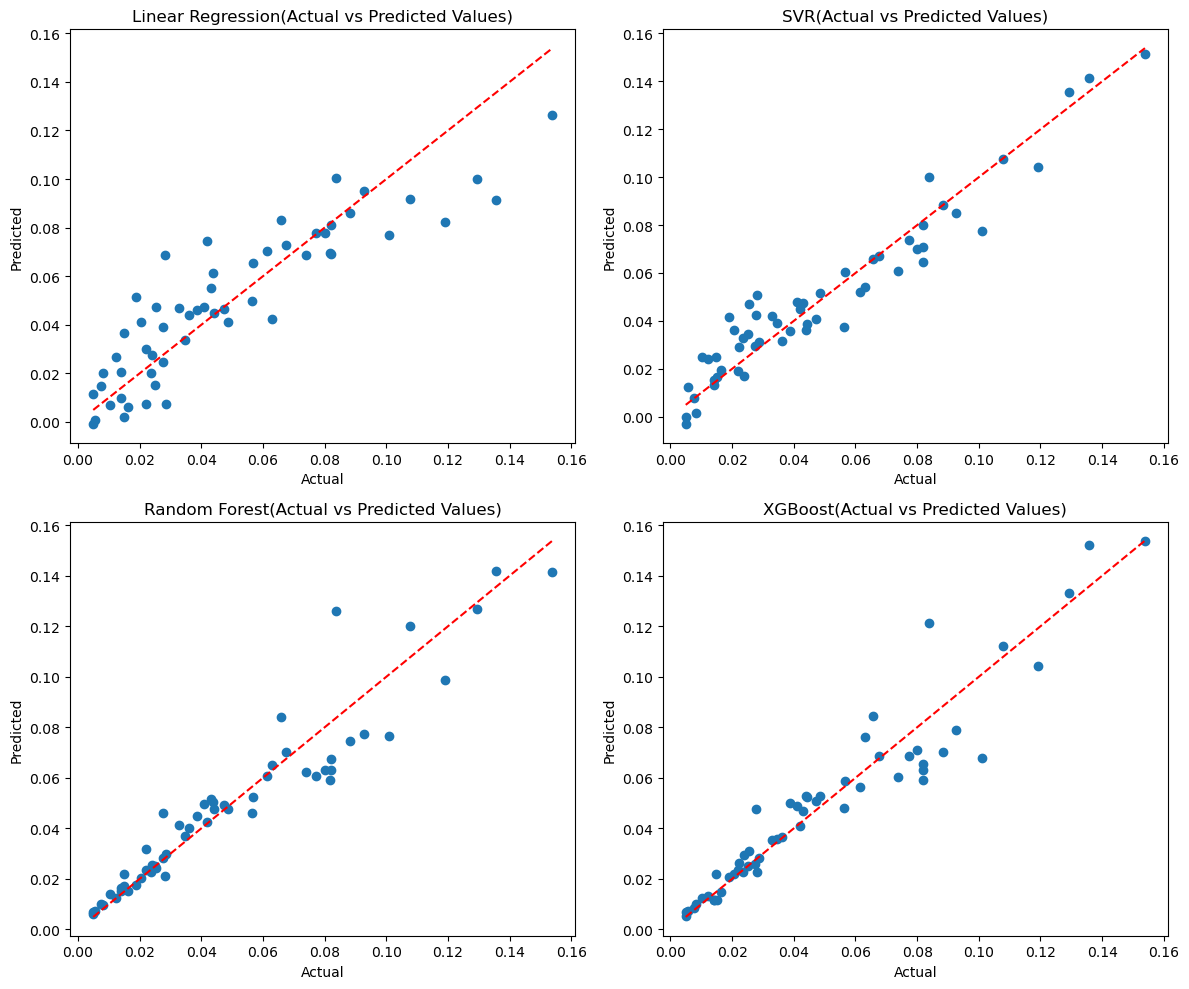

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#Evaluation metrices comparasion of all models
models = ["LR", "SVR", "Random Forest", "XGBoost"]

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_svr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb)
]

mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_svr),
    mean_absolute_error(y_test, y_pred_rf),
    mean_absolute_error(y_test, y_pred_xgb)
]

rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_xgb))
]


results_df = pd.DataFrame({
    "Model": models,
    "R2": r2_scores,
    "MAE": mae_scores,
    "RMSE": rmse_scores
})

print(results_df)


plt.figure(figsize=(7,5))
plt.bar(models, r2_scores)
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
plt.show()


plt.figure(figsize=(7,5))
plt.bar(models, mae_scores)
plt.title("Mean Absolute Error Comparison")
plt.ylabel("MAE")
plt.show()


plt.figure(figsize=(7,5))
plt.bar(models, rmse_scores)
plt.title("Root Mean Squared Error Comparison")
plt.ylabel("RMSE")
plt.show()


fig,axes = plt.subplots(2, 2, figsize=(12, 10))

# Linear Regression
axes[0,0].scatter(y_test, y_pred_lr)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0,0].set_title("Linear Regression(Actual vs Predicted Values)")
axes[0,0].set_xlabel("Actual")
axes[0,0].set_ylabel("Predicted")

# SVR
axes[0,1].scatter(y_test, y_pred_svr)
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0,1].set_title("SVR(Actual vs Predicted Values)")
axes[0,1].set_xlabel("Actual")
axes[0,1].set_ylabel("Predicted")

# Random Forest
axes[1,0].scatter(y_test, y_pred_rf)
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1,0].set_title("Random Forest(Actual vs Predicted Values)")
axes[1,0].set_xlabel("Actual")
axes[1,0].set_ylabel("Predicted")

# XGBoost
axes[1,1].scatter(y_test, y_pred_xgb)
axes[1,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1,1].set_title("XGBoost(Actual vs Predicted Values)")
axes[1,1].set_xlabel("Actual")
axes[1,1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

In [52]:
#Train-Test-Split for the KKL Data Values
_, X_test_idx, _, y_test_idx = train_test_split(df.index, df["Exp-TC"], test_size=0.2, random_state=42)
kkl_preds = df.loc[X_test_idx, "KKL-TC"].values

In [53]:
#Evaluating all models and comparing it with KKL-Model
models = ["LR", "SVR", "Random Forest", "XGBoost", "KKL"]

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_svr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_svr),
    r2_score(y_test, kkl_preds)
]

mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_svr),
    mean_absolute_error(y_test, y_pred_rf),
    mean_absolute_error(y_test, y_pred_xgb),
    mean_absolute_error(y_test, kkl_preds)
]

rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    np.sqrt(mean_squared_error(y_test, kkl_preds))
]
results_df = pd.DataFrame({
    "Model": models,
    "R2": r2_scores,
    "MAE": mae_scores,
    "RMSE": rmse_scores
})
print("ML vs KKL-Model")
print(results_df)

ML vs KKL-Model
           Model          R2       MAE      RMSE
0             LR    0.793451  0.012652  0.016464
1            SVR    0.923044  0.007857  0.010050
2  Random Forest    0.908149  0.007339  0.010979
3        XGBoost    0.923044  0.007269  0.010898
4            KKL -582.857807  0.871046  0.875348


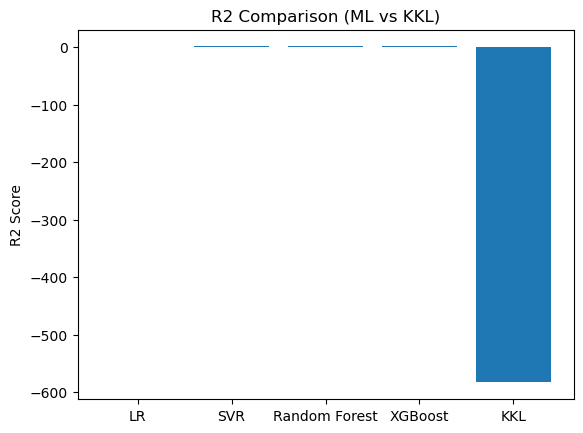

In [54]:
plt.figure()
plt.bar(models, r2_scores)
plt.title("R2 Comparison (ML vs KKL)")
plt.ylabel("R2 Score")
plt.show()

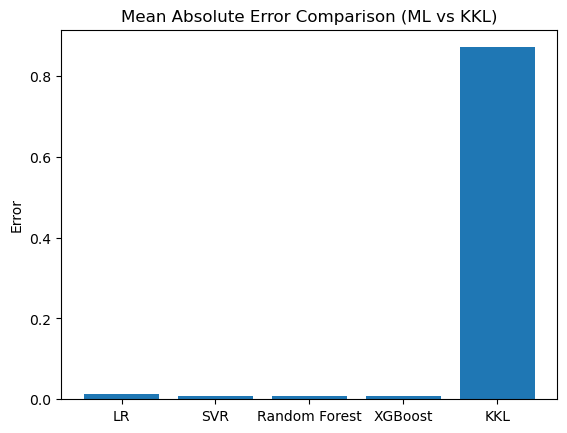

In [55]:
plt.figure()
plt.bar(models, mae_scores)
plt.title("Mean Absolute Error Comparison (ML vs KKL)")
plt.ylabel("Error")
plt.show()

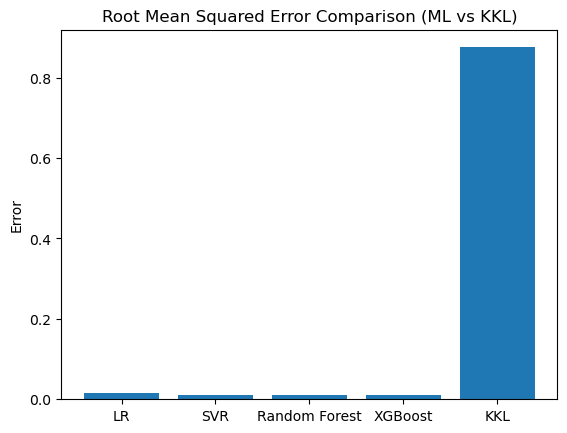

In [56]:
plt.figure()
plt.bar(models, rmse_scores)
plt.title("Root Mean Squared Error Comparison (ML vs KKL)")
plt.ylabel("Error")
plt.show()

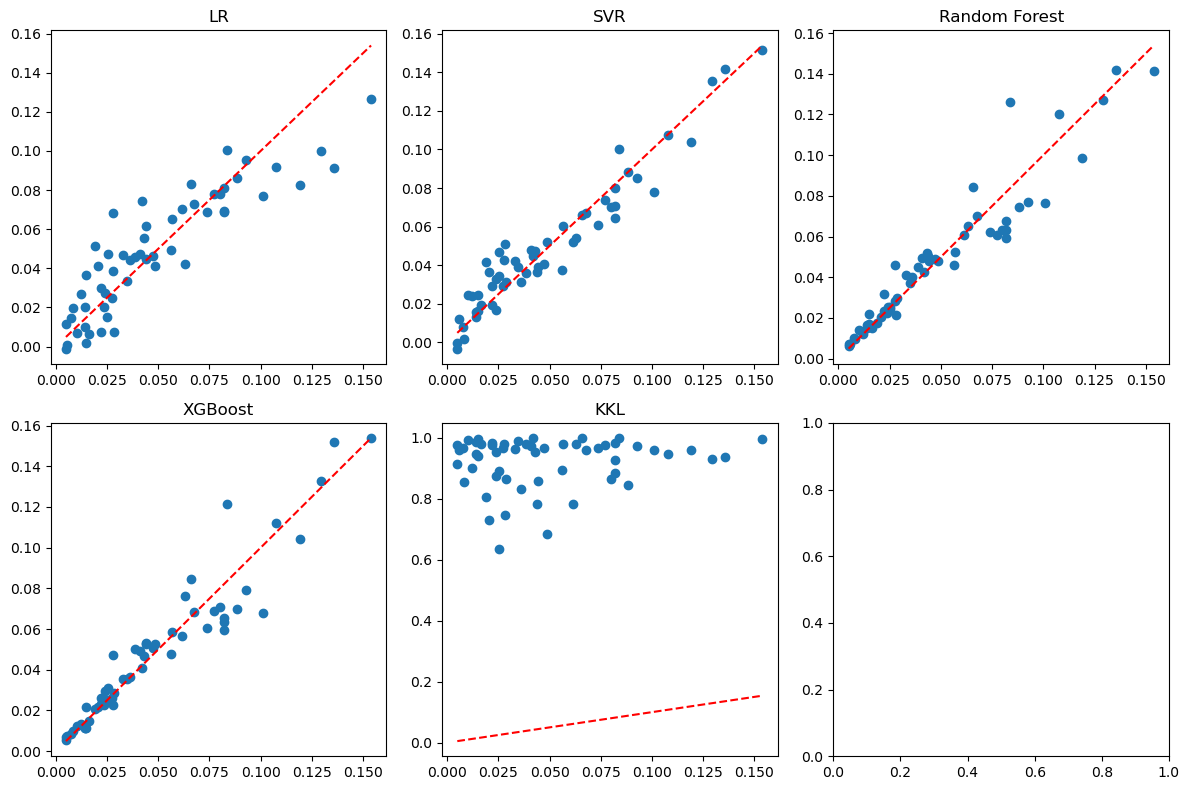

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

preds = [y_pred_lr,y_pred_svr,y_pred_rf,y_pred_xgb,kkl_preds]

for ax, pred, name in zip(axes.flatten(), preds, models):
    ax.scatter(y_test, pred)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--")
    ax.set_title(name)

plt.tight_layout()
plt.show()